### Logic flow
* load pseudopop trial_mean_FRs (trials x neurons) + one beh_trials_df
    * z-score each neuron across trials for PCA; decoding instead uses StandardScaler inside the CV pipeline so zscoring/scaling is fit on training folds only
    * neur_set toggle: all_neurs = keeps + mergers + maybes (as stacked by neur3), select_neurs = keeps only; per-region table of the drop
    * option: filter out neurons with session-wide FR < .8 Hz (filter_low_FR; off for now)
    * figs saved under outputs/pca-regression/{neur_set} (stim vs best PC) and outputs/decoding/{neur_set} (per-context decoding, CCD)
* PCA: context=shape, stim=color. 1 per region, num_neurs in title. For this, need to compute meanFR per stim, and also meanFR_per_stimPair
* per-context PCA; quantified by correlating stim with best of top 5 PCs. 1 row per region; 3*3 subplots.
* per-context class decoding: logistic regression, 5-fold stratified CV, permutation null. 3*3.
* cross-context decoding
    * sweep α, shifting C1/C3 along the stim axis to maximize decoding
    * replot cross-context decoding post-shift
    * ccd, shift, shifted-ccd can be rows; cols can be regions
* neuron-dropping curve (commented; to revisit)

* regions: all, each region, and pooled combos like ACC+OFC (a '+' label = union of its parts)
* notes:
    * assuming 3 regions, but should be generalizable

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
from utils import plot_style, norm01, stim_cmap, zscore_FRs, stim_axis; plot_style('talk');
# %matplotlib widget
%matplotlib inline

import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection
from sklearn.decomposition import PCA


### variables & functions

In [2]:
pseudopop_dir = '../../outputs/processed_data/pseudopop'

conds, thresholds, norm_thresholds = ['C1', 'C2', 'C3'], [-.2, 0, .2], [.25, .5, .75]
cond_colors = dict(zip(conds, ['orangered', 'gray', 'deepskyblue'])); print(f'conds: {conds}')
epoch = 'stim'; print(f'{epoch} epoch')

all_beh_trials_df = pd.read_csv('../../data/psychopy/all_beh_trials_df.csv'); patients = sorted(all_beh_trials_df.loc[all_beh_trials_df['eligibility'] == 'neuronal', 'subj'].unique()); print(f'neural patients: {patients}')

# pseudopop rows are in trial_key order (neur3) and every patient saw the same trial set -> one beh_trials_df stands in for all
beh_trials_df = all_beh_trials_df.loc[all_beh_trials_df['subj'] == patients[0]].sort_values('trial_key').reset_index(drop=True)
for patient in patients[1:]:
    pt_df = all_beh_trials_df.loc[all_beh_trials_df['subj'] == patient].sort_values('trial_key').reset_index(drop=True)
    assert (pt_df['trial_key'].values == beh_trials_df['trial_key'].values).all()
    assert (pt_df['true_stim'].round(2).values == beh_trials_df['true_stim'].round(2).values).all()

# trial x neuron FR, already stacked across patients by neur3; z-score each neuron across all trials pooled so no neuron dominates the population analyses
meanFRs = zscore_FRs(np.load(f'{pseudopop_dir}/{epoch}/trial_mean_FRs.npy', allow_pickle=True))
print(f'beh_trials_df: {beh_trials_df.shape} (trials, cols), meanFRs: {meanFRs.shape} (trials, neurons)')

# every analysis below runs once per region on that region's columns of meanFRs; 'all' pools every neuron
all_neurs_info_df = pd.read_parquet(f'{pseudopop_dir}/all_neurs_info_df.parquet'); all_neurs_info_df['region'] = all_neurs_info_df['region'].str[-4:-1]  # 'mRAHIP5' -> 'HIP'

# neuron set: all_neurs = keeps + mergers + maybes (everything neur3 stacked); select_neurs = keeps == 1 only (merged units are keeps; a keep with a maybe note stays). plus an optional FR floor (session-wide FR from neurs_info_df)
neur_set = ['all_neurs', 'select_neurs'][1]
filter_low_FR, min_FR = False, .8

# per-region table of what select_neurs drops
region_tab = pd.DataFrame({'all_neurs': all_neurs_info_df['region'].value_counts(), 'select_neurs': all_neurs_info_df.loc[all_neurs_info_df['keeps'] == 1, 'region'].value_counts()}).fillna(0).astype(int)
region_tab['dropped'] = region_tab['all_neurs'] - region_tab['select_neurs']; region_tab.loc['total'] = region_tab.sum(); print(f'neur_set = {neur_set}\n{region_tab}')
print(f'{(all_neurs_info_df["FR"] < min_FR).sum()}/{len(all_neurs_info_df)} neurons with FR < {min_FR} Hz' + (' -> dropped' if filter_low_FR else ' (kept; filter_low_FR off)'))

# drop maybes and/or low-FR neurons: meanFRs columns and col_idx shrink together so region slicing is unchanged
drop_mask = ((neur_set == 'select_neurs') & (all_neurs_info_df['keeps'] != 1)).values | (filter_low_FR & (all_neurs_info_df['FR'] < min_FR)).values
if drop_mask.any(): meanFRs = meanFRs[:, ~drop_mask]; all_neurs_info_df = all_neurs_info_df[~drop_mask].reset_index(drop=True); all_neurs_info_df['col_idx'] = np.arange(len(all_neurs_info_df))

# figs saved per neuron set so all_neurs / select_neurs sit side by side
decoding_dir, pca_regression_dir = f'../../outputs/figs/decoding/{neur_set}', f'../../outputs/figs/pca-regression/{neur_set}'
for out_dir in [decoding_dir, pca_regression_dir]: os.makedirs(out_dir, exist_ok=True)

regions = ['all'] + sorted(all_neurs_info_df['region'].unique()) + ['ACC+OFC']; n_regions = len(regions)
# a '+' label pools regions: ACC+OFC = union of ACC and OFC columns
region_cols = {region: all_neurs_info_df.loc[all_neurs_info_df['region'].isin(region.split('+')) | (region == 'all'), 'col_idx'].values for region in regions}
region_labels = {region: f'{region} (n={len(region_cols[region])})' for region in regions}; print(f'regions: {list(region_labels.values())}')

conds: ['C1', 'C2', 'C3']
stim epoch
neural patients: [np.float64(2512.0), np.float64(2518.0), np.float64(2521.0), np.float64(2522.0), np.float64(2605.0)]
beh_trials_df: (240, 162) (trials, cols), meanFRs: (240, 81) (trials, neurons)
neur_set = select_neurs
        all_neurs  select_neurs  dropped
region                                  
HIP            44            21       23
ACC            21            15        6
OFC            16            12        4
total          81            48       33
36/81 neurons with FR < 0.8 Hz (kept; filter_low_FR off)
regions: ['all (n=48)', 'ACC (n=15)', 'HIP (n=21)', 'OFC (n=12)', 'ACC+OFC (n=27)']


### per-cond stim x neuron means

In [3]:
# per cond: unique_stim x neuron mean FRs — trials grouped on true_stim (groupby index sorted -> stims ascending); then sliced per region
stim_by_neur, cond2stims = {region: {} for region in regions}, {}  # [region][cond]: (unique_stim, neurs); [cond]: (unique_stim,)
for cond in conds:
    cond_mask = (beh_trials_df['context'] == cond).values
    df_tmp = pd.DataFrame(meanFRs[cond_mask]); df_tmp['true_stim'] = beh_trials_df.loc[cond_mask, 'true_stim'].round(2).values
    grouped = df_tmp.groupby('true_stim').mean(); cond2stims[cond] = grouped.index.values
    for region in regions: stim_by_neur[region][cond] = grouped.values[:, region_cols[region]]
    print(f'cond2stims[{cond}]: {cond2stims[cond].shape}, stim_by_neur[region][{cond}] (unique_stim, neurs): ' + ', '.join(f'{region} {stim_by_neur[region][cond].shape}' for region in regions))

cond2stims[C1]: (15,), stim_by_neur[region][C1] (unique_stim, neurs): all (15, 48), ACC (15, 15), HIP (15, 21), OFC (15, 12), ACC+OFC (15, 27)
cond2stims[C2]: (20,), stim_by_neur[region][C2] (unique_stim, neurs): all (20, 48), ACC (20, 15), HIP (20, 21), OFC (20, 12), ACC+OFC (20, 27)
cond2stims[C3]: (15,), stim_by_neur[region][C3] (unique_stim, neurs): all (15, 48), ACC (15, 15), HIP (15, 21), OFC (15, 12), ACC+OFC (15, 27)


### merge proximal stims for SNR

In [4]:
# merge proximal unique_stim pairs to boost SNR for PCA visualization; which stims pair up depends only on the cond, so decide once and apply to every region
def stim_pair_groups(cond, n):
    if cond == 'C2': return [range(i, i+2) for i in range(0, n, 2)]                                 # C2 (base): 20 stims -> pair all -> 10
    if cond == 'C1': return [[i] for i in range(5)] + [range(i, i+2) for i in range(5, n, 2)]       # C1 (curv): only merge the last 10 stims>bound into 5 avged vals
    if cond == 'C3': return [range(i, i+2) for i in range(0, 10, 2)] + [[i] for i in range(10, n)]  # C3 (flat): only merge the first 10 stims<bound into 5 avged vals

merged_stim_by_neur, merged_cond2stims = {region: {} for region in regions}, {}
for cond in conds:
    groups = stim_pair_groups(cond, len(cond2stims[cond]))
    merged_cond2stims[cond] = np.array([cond2stims[cond][list(group)].mean() for group in groups])
    for region in regions: merged_stim_by_neur[region][cond] = np.array([stim_by_neur[region][cond][list(group)].mean(axis=0) for group in groups])
    print(f'merged_cond2stims[{cond}]:   {merged_cond2stims[cond]}')
    print(f'merged_stim_by_neur[all][{cond}]: {merged_stim_by_neur["all"][cond].shape} FRs\n')

merged_cond2stims[C1]:   [-0.38 -0.34 -0.3  -0.26 -0.22 -0.16 -0.08  0.    0.08  0.16]
merged_stim_by_neur[all][C1]: (10, 48) FRs

merged_cond2stims[C2]:   [-0.36 -0.28 -0.2  -0.12 -0.04  0.04  0.12  0.2   0.28  0.36]
merged_stim_by_neur[all][C2]: (10, 48) FRs

merged_cond2stims[C3]:   [-0.16 -0.08  0.    0.08  0.16  0.22  0.26  0.3   0.34  0.38]
merged_stim_by_neur[all][C3]: (10, 48) FRs



### 1. population PCA across contexts

In [5]:
from matplotlib.colors import Normalize

# SETTINGS
space    = ['Original', 'Aligned'][0]   # Aligned = per-condition mean subtracted before PCA
color_by = ['stim', 'stim_aligned'][0]  # stim_aligned = position relative to condition boundary

# stim metadata is region-independent: every region sees the same merged stims x conds, stacked cond by cond
pca_df_stim = pd.DataFrame([{'stim': s, 'context': cond, 'class': int(s > thresh), 'stim_aligned': round(s - thresh, 4)}
                            for cond, thresh in zip(conds, thresholds) for s in merged_cond2stims[cond]])

# per region: stack all conditions' stim-averaged vectors so PCA finds one shared space
pca_mtx_stim, pca_dfs_stim = {}, {}
for region in regions:
    pca_mtx_stim[region] = np.vstack([merged_stim_by_neur[region][cond] for cond in conds])  # (n_total_stims, n_neurs)

    # subtract per-condition mean before PCA so variance reflects within-context geometry
    pca_input = pca_mtx_stim[region].copy()
    if space == 'Aligned':
        for cond in conds:
            mask = (pca_df_stim['context'] == cond).values; pca_input[mask] -= pca_input[mask].mean(axis=0)

    pca_stim = PCA(n_components=3); pcs = pca_stim.fit_transform(pca_input); ev = pca_stim.explained_variance_ratio_
    pca_dfs_stim[region] = pca_df_stim.assign(PC1=pcs[:, 0], PC2=pcs[:, 1], PC3=pcs[:, 2])
    print(f'PCA ({space}), {region_labels[region]} — PC1: {ev[0]*100:.1f}%,  PC2: {ev[1]*100:.1f}%,  PC3: {ev[2]*100:.1f}%')

PCA (Original), all (n=48) — PC1: 10.9%,  PC2: 10.2%,  PC3: 8.0%
PCA (Original), ACC (n=15) — PC1: 15.9%,  PC2: 14.2%,  PC3: 13.6%
PCA (Original), HIP (n=21) — PC1: 15.4%,  PC2: 13.4%,  PC3: 12.5%
PCA (Original), OFC (n=12) — PC1: 19.4%,  PC2: 15.0%,  PC3: 14.0%
PCA (Original), ACC+OFC (n=27) — PC1: 14.2%,  PC2: 11.7%,  PC3: 10.1%


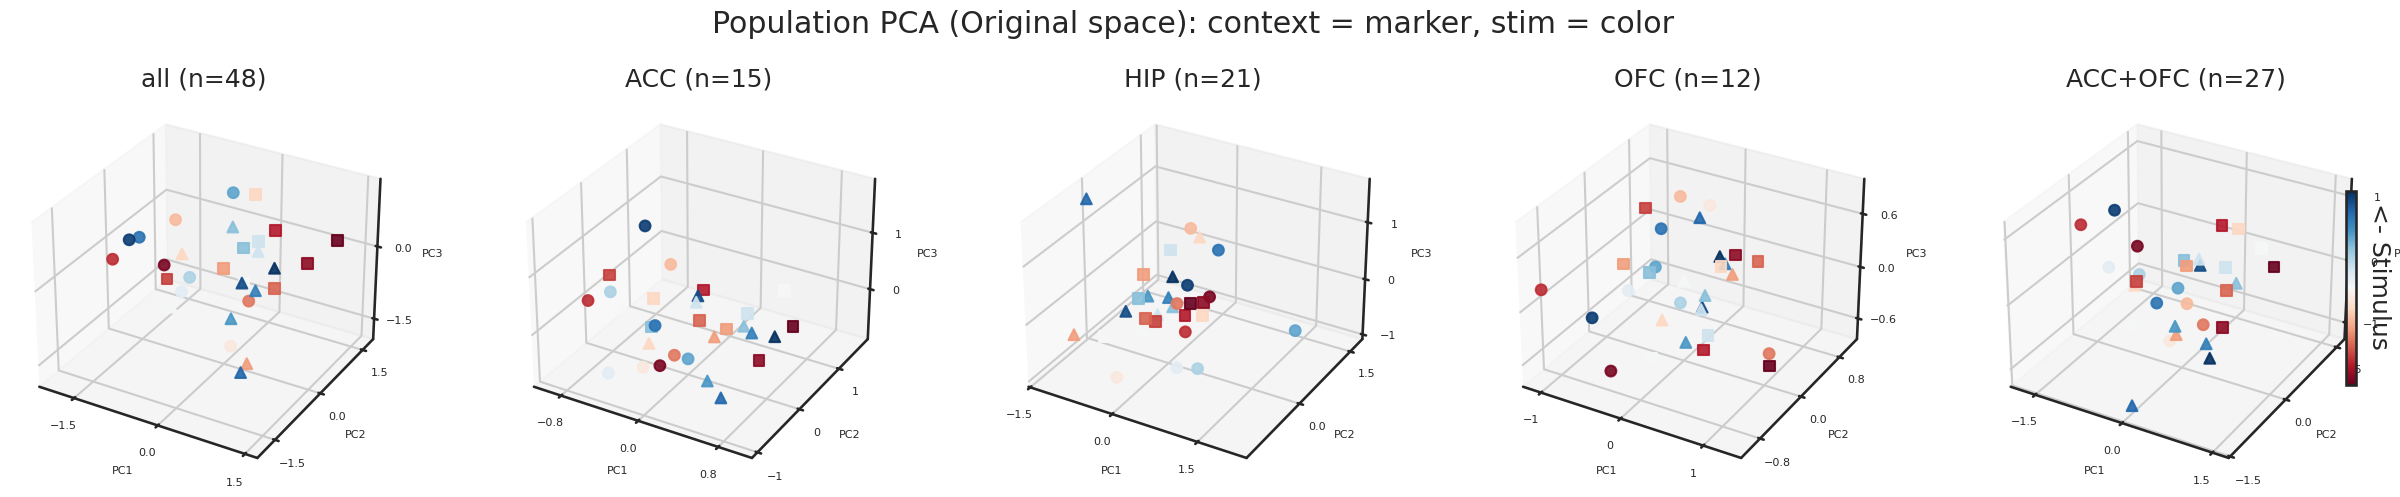

In [6]:
cmap_stim    = plt.cm.RdBu
cond_markers = dict(zip(conds, ['s', 'o', '^']))

color_vals = pca_df_stim[color_by].values
if color_by == 'stim_aligned':
    absmax    = np.abs(color_vals).max()
    norm_stim = Normalize(vmin=-absmax, vmax=absmax)
else:
    norm_stim = Normalize(vmin=color_vals.min(), vmax=color_vals.max())

fig = plt.figure(figsize=(5 * n_regions, 5)); plt.suptitle(f'Population PCA ({space} space): context = marker, stim = color', y=1.0)

for i, region in enumerate(regions):
    ax = fig.add_subplot(1, n_regions, i + 1, projection='3d')
    ax.set(title=region_labels[region], xlabel='PC1', ylabel='PC2', zlabel='PC3')

    for cond in conds:
        cdf    = pca_dfs_stim[region][pca_dfs_stim[region]['context'] == cond]
        colors = cmap_stim(norm_stim(cdf[color_by].values))
        ax.scatter(cdf['PC1'], cdf['PC2'], cdf['PC3'], c=colors, s=60, alpha=0.9, marker=cond_markers[cond])

    ax.tick_params(labelsize=8)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_major_locator(plt.MaxNLocator(3))
        axis.label.set_size(8)

legend_handles = [
    plt.Line2D([0], [0], marker=cond_markers[cond], color='w',
               markerfacecolor='none', markeredgecolor='k', markersize=8, label=cond)
    for cond in conds
]
# ax.legend(handles=legend_handles, frameon=True)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm_stim, cmap=cmap_stim), ax=ax,
                    pad=-.05, shrink=0.5)
cbar.set_label('<- Stimulus   ', rotation=270, labelpad=25)
cbar.set_ticks([])

plt.tight_layout(); plt.show()

### 2. per-context PCA, colored by stim

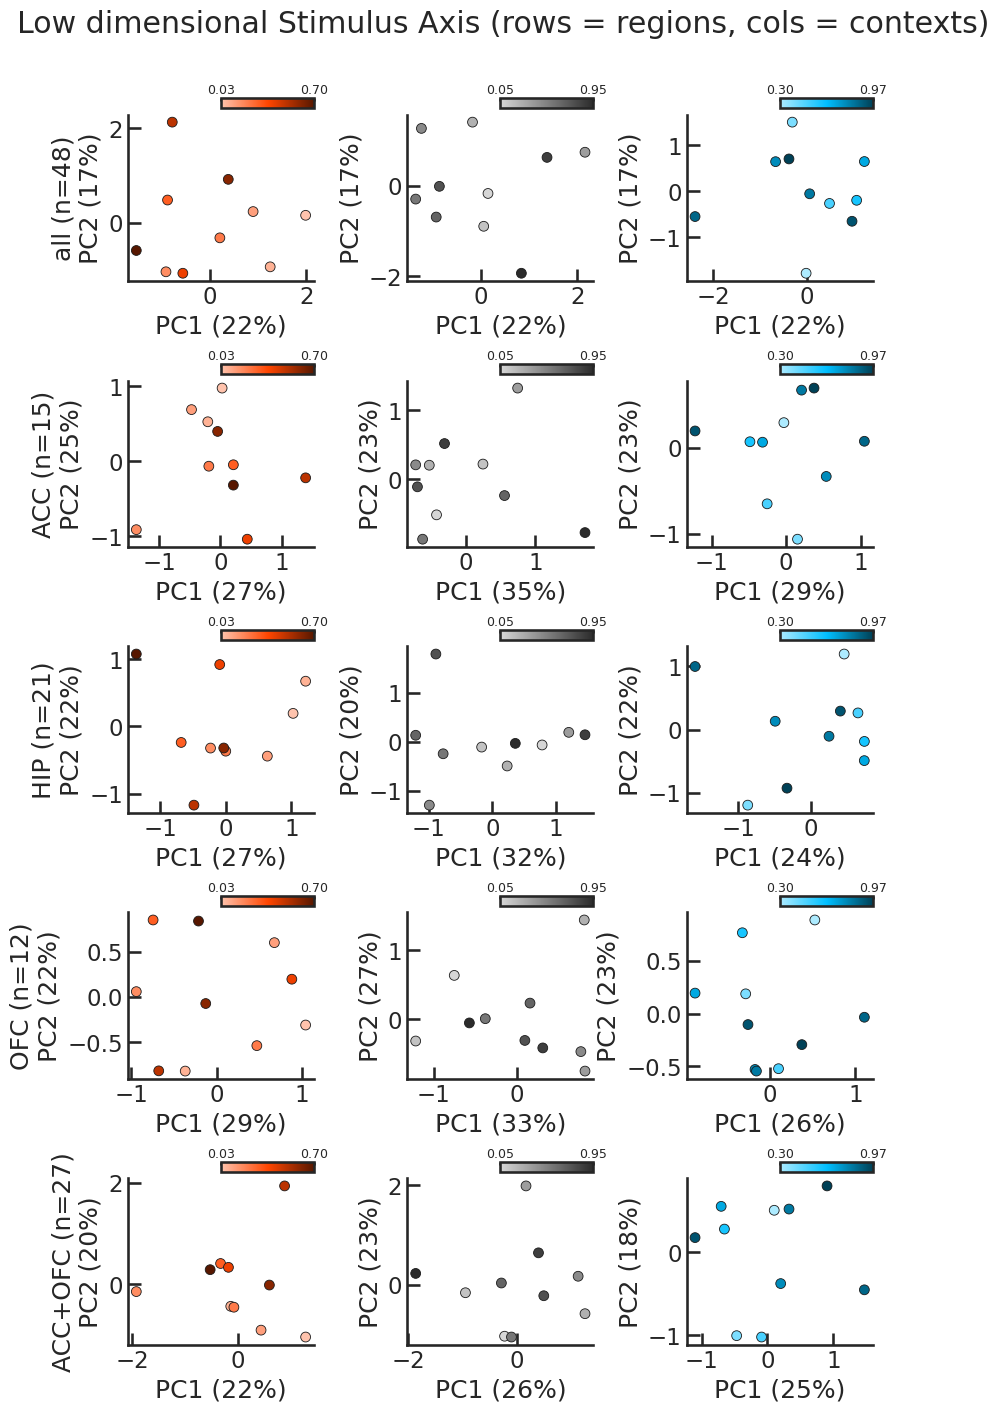

In [7]:
fig, axs = plt.subplots(n_regions, 3, figsize=(10, 3 * n_regions))
plt.suptitle(f'Low dimensional Stimulus Axis (rows = regions, cols = contexts)', y=1.0)  # raised to clear the per-panel colorbars
cond_markers = dict(zip(conds, ['s', 'o', '^']))

for row, region in enumerate(regions):
    for i, (ax, cond) in enumerate(zip(axs[row], conds)):

        stims = merged_cond2stims[cond]
        pca = PCA(n_components=2)
        coords, var = pca.fit_transform(merged_stim_by_neur[region][cond]), pca.explained_variance_ratio_
        cmap = stim_cmap(cond_colors[cond])

        # region named once per row, on the first column's y-label
        ax.set(xlabel=f'PC1 ({var[0]*100:.0f}%)', ylabel=(f'{region_labels[region]}\n' if i == 0 else '') + f'PC2 ({var[1]*100:.0f}%)')
        # shade by stim (normed within context, to use the full ramp) so PC geometry can be read against stim order
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=norm01(stims), cmap=cmap, vmin=0, vmax=1, s=50, edgecolors='k', linewidths=.6)

        # PC axes carry no stim, so the ramp needs its own key; ends label this context's true stim range
        lo, hi = (stims.min() + .4) / .8, (stims.max() + .4) / .8
        cax = ax.inset_axes([.5, 1.04, .5, .06])
        plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(lo, hi), cmap=cmap), cax=cax, orientation='horizontal', ticks=[lo, hi])
        cax.set(xticklabels=[f'{lo:.2f}', f'{hi:.2f}'])
        cax.xaxis.set_ticks_position('top'); cax.tick_params(labelsize=9, length=2, pad=1)

plt.subplots_adjust(right=0.87, top=0.93, wspace=.5, hspace=.6)  # top/hspace leave room for the colorbars
plt.show()

### quantify: stim vs. best PC

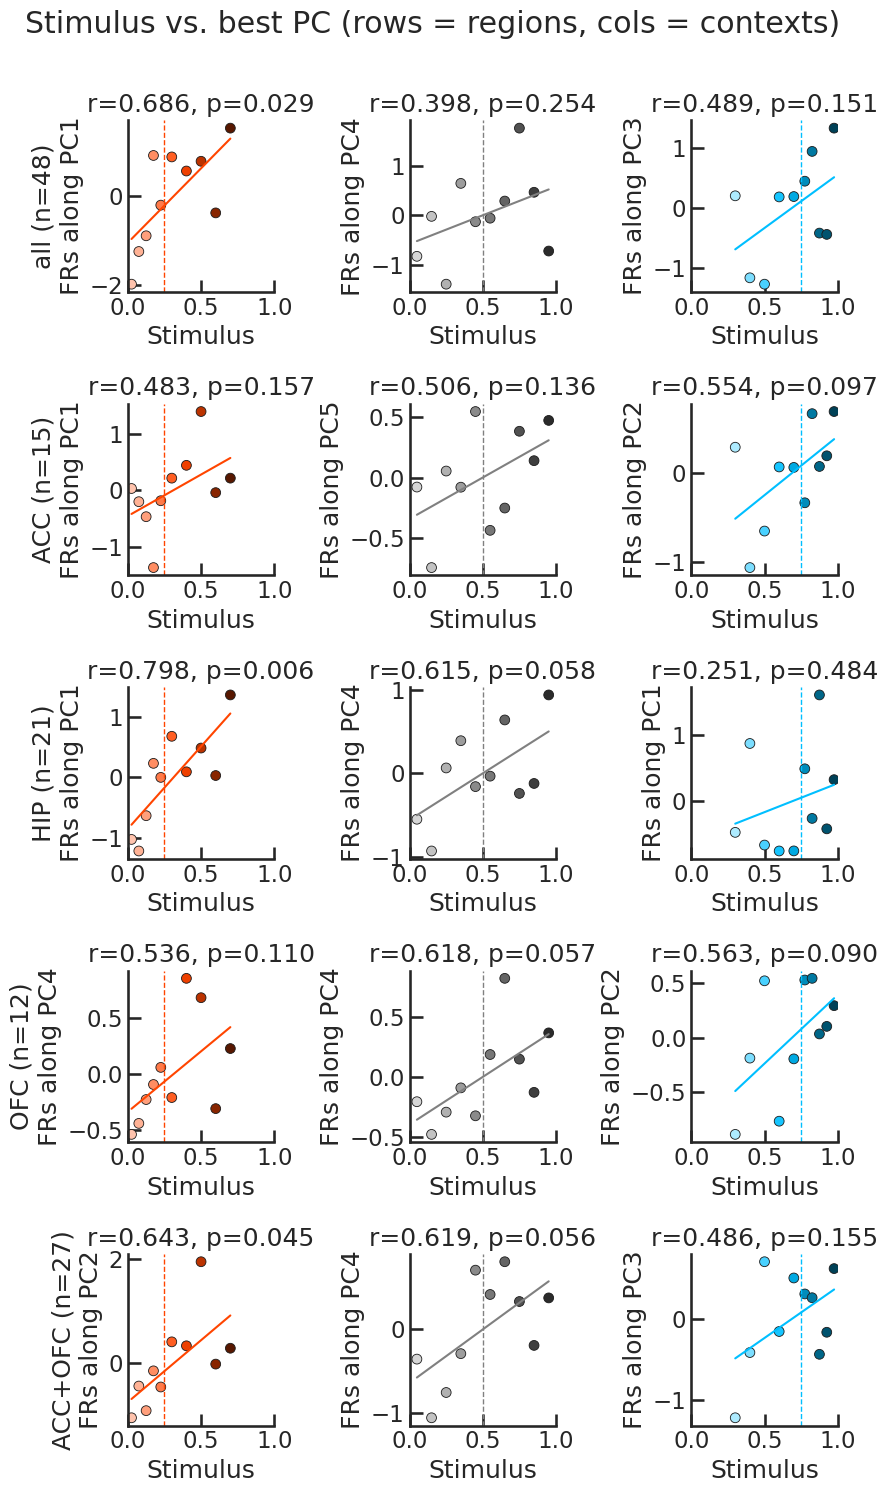

In [8]:
from scipy.stats import pearsonr, spearmanr

fig, axs = plt.subplots(n_regions, 3, figsize=(9, 3 * n_regions))
plt.suptitle('Stimulus vs. best PC (rows = regions, cols = contexts)', y=1.0)
norm_ticks, norm_ticklabels = np.linspace(-.4, .4, 3), np.linspace(0, 1, 3)
n_pcs = 5

for row, region in enumerate(regions):
    for i, (ax, cond) in enumerate(zip(axs[row], conds)):

        stims, FRs = merged_cond2stims[cond], merged_stim_by_neur[region][cond]

        pca = PCA(n_components=n_pcs).fit(FRs)
        FRs_pcs = pca.transform(FRs)
        all_corrs = [np.corrcoef(stims, FRs_pcs[:, i])[0, 1] for i in range(n_pcs)]
        best_pc = np.argmax(np.abs(all_corrs))
        sign = np.sign(all_corrs[best_pc])
        FRs_best_pc = sign * FRs_pcs[:, best_pc]

        r, p = pearsonr(stims, FRs_best_pc)

        # region named once per row, on the first column's y-label; y-scale left free since PC magnitudes shrink with fewer neurons
        ax.set(title=f'r={r:.3f}, p={p:.3f}', xlabel='Stimulus', ylabel=(f'{region_labels[region]}\n' if i == 0 else '') + f'FRs along PC{best_pc+1}', xlim=(-.4,.4), xticks=norm_ticks, xticklabels=norm_ticklabels)
        ax.axvline(thresholds[i], color=cond_colors[cond], ls='--', linewidth=1)
        # shade by stim (normed within context, to use the full ramp) to match the PCA panels above
        ax.scatter(stims, FRs_best_pc, c=norm01(stims), cmap=stim_cmap(cond_colors[cond]), vmin=0, vmax=1, s=50, edgecolors='k', linewidths=.6)
        m, b = np.polyfit(stims, FRs_best_pc, 1)
        ax.plot(stims, m * stims + b, color=cond_colors[cond], linewidth=1.5)

plt.tight_layout()
plt.savefig(f'{pca_regression_dir}/{epoch}_stim_axis.png', dpi=300, bbox_inches='tight'); plt.show()

### 3. class decoding per context vs. permuted chance

In [9]:
# per region x cond: X = trial x neuron FRs; y = class label (stim above/below the condition boundary), the same for every region
cond_decode_X, cond_decode_y = {region: {} for region in regions}, {}
for cond in conds:
    cond_mask = (beh_trials_df['context'] == cond).values
    cond_decode_y[cond] = (beh_trials_df.loc[cond_mask, 'stim_thresh_aligned'] > 0).astype(int).values
    assert cond_mask.sum() == 80; assert cond_decode_y[cond].sum() == 40  # 40 1s, 40 0s
    for region in regions: cond_decode_X[region][cond] = meanFRs[cond_mask][:, region_cols[region]]

for region in regions: assert cond_decode_X[region]['C1'].shape == cond_decode_X[region]['C2'].shape == cond_decode_X[region]['C3'].shape
print('All matrices have the same (trials, neurs) within a region: ' + ', '.join(f'{region} {cond_decode_X[region]["C1"].shape}' for region in regions))

All matrices have the same (trials, neurs) within a region: all (80, 48), ACC (80, 15), HIP (80, 21), OFC (80, 12), ACC+OFC (80, 27)


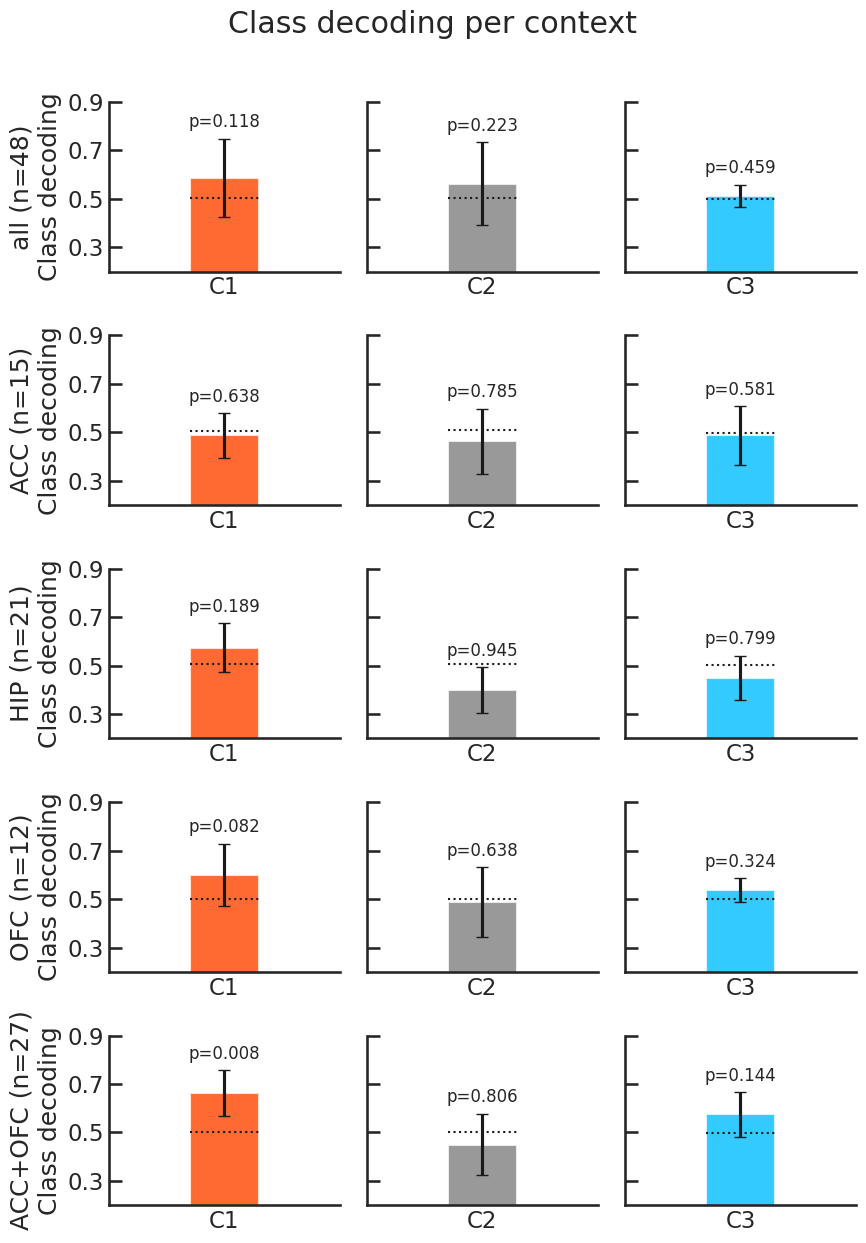

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler; from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score

# scaler inside the pipeline -> fit on training folds only; default L2 gives a finite optimum (unpenalized LR never converges when neurs ~ trials make classes separable)
clf = make_pipeline(StandardScaler(), LogisticRegression())
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
n_perms, random_state = 1000, 0

def decode_vs_null(X, y):
    ''' CV accuracy against a label-permutation null; fold spread gives the error bar '''
    score, perm_scores, pvalue = permutation_test_score(clf, X, y, cv=cv, scoring='accuracy', n_permutations=n_perms, random_state=random_state, n_jobs=-1)
    fold_accs = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
    return score, perm_scores.mean(), pvalue, fold_accs.std()

def plot_decode_bar(ax, x, score, null_mean, pvalue, fold_std, color):
    ''' one bar: accuracy ± fold std, dotted null mean, p-value above '''
    ax.bar(x, score, yerr=fold_std, color=color, alpha=0.8, capsize=4, width=0.6)
    ax.hlines(null_mean, x - 0.3, x + 0.3, colors='k', linestyles='dotted', linewidth=1.5)
    ax.text(x, score + fold_std + 0.03, f'p={pvalue:.3f}', ha='center', va='bottom', fontsize=12)

# rows = regions, cols = contexts; y-range opens below chance since aligned data can sit there
fig, axs = plt.subplots(n_regions, 3, figsize=(9, 2.5 * n_regions), sharey=True); plt.suptitle('Class decoding per context', y=1.0)
for row, region in enumerate(regions):
    for i, (ax, cond) in enumerate(zip(axs[row], conds)):
        ax.set(xticks=[0], xticklabels=[cond], xlim=(-1, 1), ylim=(.2, .9), yticks=[.3, .5, .7, .9], ylabel=f'{region_labels[region]}\nClass decoding' if i == 0 else '')
        ax.tick_params(axis='x', length=0)
        plot_decode_bar(ax, 0, *decode_vs_null(cond_decode_X[region][cond], cond_decode_y[cond]), cond_colors[cond])

plt.tight_layout(); plt.savefig(f'{decoding_dir}/{epoch}_class_decoding_per_context.png', dpi=300, bbox_inches='tight'); plt.show()

### 5. cross-context decoding (CCD)

In [11]:
def align_contexts_dict(X_dict):
    """Subtract per-condition mean — removes condition offset before decoding."""
    return {cond: X - X.mean(axis=0) for cond, X in X_dict.items()}

# SETTINGS
alignment_label = ['Original Space', 'Aligned Space'][0]
alignment = alignment_label == 'Aligned Space'

def ccd_matrix(X_dict):
    ''' train on one context, test on every context -> (train, test) accuracy matrix '''
    ccd = np.zeros((len(conds), len(conds)))
    for i, cond_tr in enumerate(conds):
        clf.fit(X_dict[cond_tr], cond_decode_y[cond_tr])
        for j, cond_te in enumerate(conds):
            # scoring a model on its own training trials would give ~100% (neurs ~ trials); cross-validate the diagonal so it means within-context generalization, comparable to off-diag
            if i == j: ccd[i, j] = cross_val_score(clf, X_dict[cond_te], cond_decode_y[cond_te], cv=cv, scoring='accuracy').mean()
            else: ccd[i, j] = clf.score(X_dict[cond_te], cond_decode_y[cond_te])
    return ccd
offdiag_mean = lambda ccd: ccd[~np.eye(len(conds), dtype=bool)].mean()  # generalization across contexts = off-diagonal cells

# CCD per region; plotted below as the top row of the CCD figure
ccd_acc = {region: ccd_matrix(align_contexts_dict(cond_decode_X[region]) if alignment else cond_decode_X[region]) for region in regions}
for region in regions: print(f'{region_labels[region]}: avg off-diag CCD {offdiag_mean(ccd_acc[region])*100:.1f}%')

all (n=48): avg off-diag CCD 50.0%
ACC (n=15): avg off-diag CCD 46.0%
HIP (n=21): avg off-diag CCD 45.8%
OFC (n=12): avg off-diag CCD 53.8%
ACC+OFC (n=27): avg off-diag CCD 49.6%


### stim-axis alignment: sweep α per region, replot CCD post-shift

In [12]:
# one stim axis per region: slope of each neuron vs stim across all trials pooled (all contexts) -> the direction the population moves as stim increases
all_trial_stims = beh_trials_df['true_stim'].round(2).values
region_stim_axis = {region: stim_axis(meanFRs[:, region_cols[region]], all_trial_stims) for region in regions}

def apply_stim_shift(region, alpha):
    ''' slide all of C1 by +alpha and all of C3 by -alpha along the stim axis; C2 unchanged.
        one constant vector per context, so a trial's shift never depends on its own stim (that would leak the class label into the features) '''
    X_shifted = {cond: cond_decode_X[region][cond].copy() for cond in conds}
    X_shifted['C1'] += alpha * region_stim_axis[region]; X_shifted['C3'] -= alpha * region_stim_axis[region]
    return X_shifted

# sweep α per region: the shift that best restores cross-context generalization (data is z-scored, so α is in z units; C1-C3 centroid gap along the axis is ~1.4)
alphas = np.linspace(-3, 3, 100)
alpha_accs, best_alpha = {}, {}
for region in regions:
    alpha_accs[region] = np.array([offdiag_mean(ccd_matrix(apply_stim_shift(region, a))) for a in alphas])
    best_alpha[region] = alphas[np.argmax(alpha_accs[region])]
    print(f'{region_labels[region]}: best α={best_alpha[region]:.3f},  off-diag CCD={alpha_accs[region].max()*100:.2f}%')

all (n=48): best α=-0.455,  off-diag CCD=50.83%


ACC (n=15): best α=0.818,  off-diag CCD=50.21%


HIP (n=21): best α=-1.303,  off-diag CCD=50.00%


OFC (n=12): best α=0.697,  off-diag CCD=56.46%


ACC+OFC (n=27): best α=2.273,  off-diag CCD=53.75%


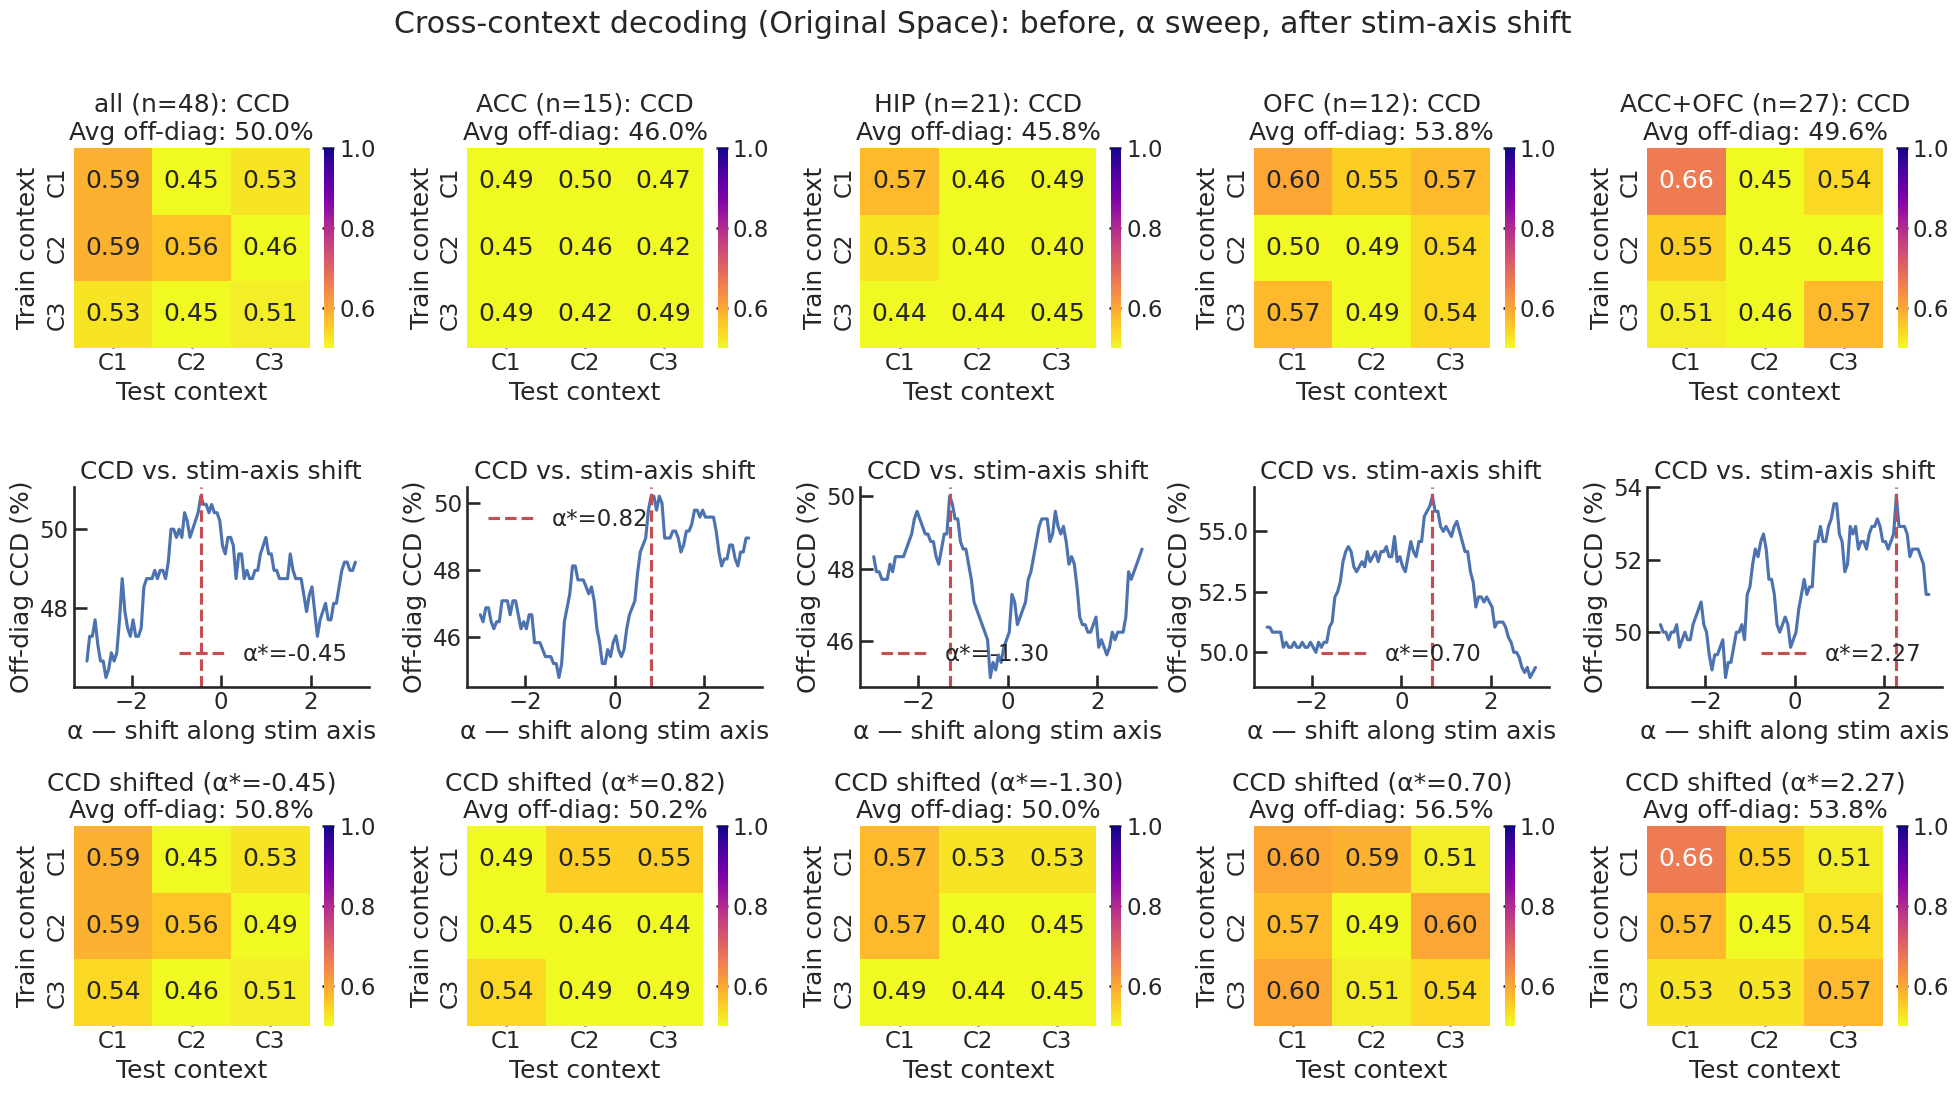

In [13]:
# CCD after shifting each region by its own best α
ccd_acc_shifted = {region: ccd_matrix(apply_stim_shift(region, best_alpha[region])) for region in regions}

# rows = [CCD, α sweep, shifted CCD]; cols = regions
fig, axs = plt.subplots(3, n_regions, figsize=(4 * n_regions, 11)); plt.suptitle(f'Cross-context decoding ({alignment_label}): before, α sweep, after stim-axis shift', y=1.0)
for col, region in enumerate(regions):

    ax = axs[0, col]
    sns.heatmap(ccd_acc[region], annot=True, fmt='.2f', xticklabels=conds, yticklabels=conds, cmap='plasma_r', vmin=.5, vmax=1, ax=ax)
    ax.set(title=f'{region_labels[region]}: CCD\nAvg off-diag: {offdiag_mean(ccd_acc[region])*100:.1f}%', xlabel='Test context', ylabel='Train context')

    ax = axs[1, col]
    ax.plot(alphas, alpha_accs[region] * 100)
    ax.axvline(best_alpha[region], color='r', ls='--', label=f'α*={best_alpha[region]:.2f}')
    ax.set(xlabel='α — shift along stim axis', ylabel='Off-diag CCD (%)', title='CCD vs. stim-axis shift')
    ax.legend(frameon=False)

    ax = axs[2, col]
    sns.heatmap(ccd_acc_shifted[region], annot=True, fmt='.2f', xticklabels=conds, yticklabels=conds, cmap='plasma_r', vmin=.5, vmax=1, ax=ax)
    ax.set(title=f'CCD shifted (α*={best_alpha[region]:.2f})\nAvg off-diag: {offdiag_mean(ccd_acc_shifted[region])*100:.1f}%', xlabel='Test context', ylabel='Train context')

plt.tight_layout(); plt.savefig(f'{decoding_dir}/{epoch}_cross_context_decoding.png', dpi=300, bbox_inches='tight'); plt.show()

### 6. neuron-dropping curve

In [14]:
# import warnings
# from sklearn.exceptions import ConvergenceWarning
# warnings.filterwarnings('ignore', category=ConvergenceWarning)  # unpenalized LR can fail to converge as n_neurons -> n_trials; doesn't affect CV accuracy

# def neuron_dropping_curve(X, y, n_neurons_list, clf, cv, n_subsets=20, n_shuffles=20, seed=0):
#     """For each n in n_neurons_list, draw n_subsets random neuron subsets of that size;
#     per subset, CV-score on true labels (real) and on n_shuffles label-permutations (null)."""
#     rng = np.random.default_rng(seed)
#     n_total = X.shape[1]
#     real_accs, null_accs = np.zeros((len(n_neurons_list), n_subsets)), np.zeros((len(n_neurons_list), n_subsets * n_shuffles))

#     for i, n in enumerate(n_neurons_list):
#         for k in range(n_subsets):
#             neur_idx = rng.choice(n_total, size=n, replace=False)
#             Xs = X[:, neur_idx]

#             real_accs[i, k] = cross_val_score(clf, Xs, y, cv=cv, scoring='accuracy').mean()

#             for j in range(n_shuffles):
#                 y_shuf = rng.permutation(y)
#                 null_accs[i, k * n_shuffles + j] = cross_val_score(clf, Xs, y_shuf, cv=cv, scoring='accuracy').mean()

#     return real_accs, null_accs

# n_total_neurs   = cond_decode_X['C1'].shape[1]
# n_neurons_list  = sorted(set([2, 5, 10, 15, 20, 30, 40, n_total_neurs]))

# fig, ax = plt.subplots(figsize=(6, 4))
# ax.set(xlabel='# neurons', ylabel='Class decoding', ylim=(.4, .9), yticks=[.5, .6, .7, .8])

# for cond in conds:
#     X, y = cond_decode_X[cond], cond_decode_y[cond]
#     real_accs, null_accs = neuron_dropping_curve(X, y, n_neurons_list, clf, cv)

#     real_mean, real_sem = real_accs.mean(axis=1), real_accs.std(axis=1) / np.sqrt(real_accs.shape[1])
#     null_mean, null_sem = null_accs.mean(axis=1), null_accs.std(axis=1) / np.sqrt(null_accs.shape[1])

#     ax.plot(n_neurons_list, real_mean, color=cond_colors[cond], marker='o', label=cond)
#     ax.fill_between(n_neurons_list, real_mean - real_sem, real_mean + real_sem, color=cond_colors[cond], alpha=0.2)

#     ax.plot(n_neurons_list, null_mean, color=cond_colors[cond], ls='dotted', linewidth=1.5)
#     ax.fill_between(n_neurons_list, null_mean - null_sem, null_mean + null_sem, color=cond_colors[cond], alpha=0.1)

# ax.legend(frameon=False)
# plt.tight_layout(); plt.show()